In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the data
df = pd.read_csv('loan_predection.csv')

print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (614, 13)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [2]:
# Data Preprocessing Steps

# 1. Drop Loan_ID
df = df.drop('Loan_ID', axis=1)

# 2. Handle missing values
def handle_missing_values(df):
    df_clean = df.copy()
    
    # Numerical columns - fill with median
    numerical_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
    for col in numerical_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # Categorical columns - fill with mode
    categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
    for col in categorical_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown')
    
    return df_clean

df_clean = handle_missing_values(df)

# 3. Feature Engineering
df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
df_clean['IncomeToLoanRatio'] = df_clean['TotalIncome'] / df_clean['LoanAmount']
df_clean['LoanAmount_log'] = np.log1p(df_clean['LoanAmount'])
df_clean['TotalIncome_log'] = np.log1p(df_clean['TotalIncome'])

# 4. Encode categorical variables
categorical_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

label_encoders = {}
for col in categorical_cols:
    if col in df_clean.columns:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        label_encoders[col] = le

print("Data after preprocessing:")
print(df_clean.head())
print(f"\nShape: {df_clean.shape}")
print(f"Missing values: {df_clean.isnull().sum().sum()}")

Data after preprocessing:
   Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        0           0          0              0             5849   
1       1        1           1          0              0             4583   
2       1        1           0          0              1             3000   
3       1        1           0          1              0             2583   
4       1        0           0          0              0             6000   

   CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History  \
0                0.0       128.0             360.0             1.0   
1             1508.0       128.0             360.0             1.0   
2                0.0        66.0             360.0             1.0   
3             2358.0       120.0             360.0             1.0   
4                0.0       141.0             360.0             1.0   

   Property_Area  Loan_Status  TotalIncome  IncomeToLoanRatio  LoanAmount_log  \
0        

In [3]:
# Prepare features and target
X = df_clean.drop('Loan_Status', axis=1)
y = df_clean['Loan_Status']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in training: {np.bincount(y_train)}")
print(f"Class distribution in test: {np.bincount(y_test)}")

Training set: (429, 15)
Test set: (185, 15)
Class distribution in training: [134 295]
Class distribution in test: [ 58 127]


In [4]:
# Experiment 1: Logistic Regression without GridSearchCV
print("=" * 60)
print("التجربة 1: Logistic Regression بدون GridSearchCV")
print("=" * 60)

# L1 Regularization (Lasso)
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
lr_l1.fit(X_train_scaled, y_train)

# L2 Regularization (Ridge)
lr_l2 = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)
lr_l2.fit(X_train_scaled, y_train)

# Evaluate both models
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    return {
        'Model': model_name,
        'Train_Accuracy': train_acc,
        'Test_Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1
    }

# Evaluate L1 and L2
results_lr_l1 = evaluate_model(lr_l1, X_train_scaled, X_test_scaled, y_train, y_test, "LR L1")
results_lr_l2 = evaluate_model(lr_l2, X_train_scaled, X_test_scaled, y_train, y_test, "LR L2")

print("L1 Regularization Results:")
print(f"Train Accuracy: {results_lr_l1['Train_Accuracy']:.4f}")
print(f"Test Accuracy: {results_lr_l1['Test_Accuracy']:.4f}")
print(f"Precision: {results_lr_l1['Precision']:.4f}")
print(f"Recall: {results_lr_l1['Recall']:.4f}")
print(f"F1-Score: {results_lr_l1['F1_Score']:.4f}")

print("\nL2 Regularization Results:")
print(f"Train Accuracy: {results_lr_l2['Train_Accuracy']:.4f}")
print(f"Test Accuracy: {results_lr_l2['Test_Accuracy']:.4f}")
print(f"Precision: {results_lr_l2['Precision']:.4f}")
print(f"Recall: {results_lr_l2['Recall']:.4f}")
print(f"F1-Score: {results_lr_l2['F1_Score']:.4f}")

التجربة 1: Logistic Regression بدون GridSearchCV
L1 Regularization Results:
Train Accuracy: 0.7949
Test Accuracy: 0.8541
Precision: 0.8333
Recall: 0.9843
F1-Score: 0.9025

L2 Regularization Results:
Train Accuracy: 0.7949
Test Accuracy: 0.8541
Precision: 0.8333
Recall: 0.9843
F1-Score: 0.9025


In [5]:
# Experiment 2: Decision Tree without GridSearchCV
print("\n" + "=" * 60)
print("التجربة 2: Decision Tree بدون GridSearchCV")
print("=" * 60)

# Basic Decision Tree
dt_basic = DecisionTreeClassifier(random_state=42)
dt_basic.fit(X_train, y_train)

# Evaluate Decision Tree
results_dt_basic = evaluate_model(dt_basic, X_train, X_test, y_train, y_test, "DT Basic")

print("Decision Tree Results:")
print(f"Train Accuracy: {results_dt_basic['Train_Accuracy']:.4f}")
print(f"Test Accuracy: {results_dt_basic['Test_Accuracy']:.4f}")
print(f"Precision: {results_dt_basic['Precision']:.4f}")
print(f"Recall: {results_dt_basic['Recall']:.4f}")
print(f"F1-Score: {results_dt_basic['F1_Score']:.4f}")


التجربة 2: Decision Tree بدون GridSearchCV
Decision Tree Results:
Train Accuracy: 1.0000
Test Accuracy: 0.7189
Precision: 0.8378
Recall: 0.7323
F1-Score: 0.7815


In [6]:
# Experiment 3: Logistic Regression with GridSearchCV
print("\n" + "=" * 60)
print("التجربة 3: Logistic Regression مع GridSearchCV")
print("=" * 60)

# Define parameter grid for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

# GridSearchCV for Logistic Regression
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train_scaled, y_train)

# Best model
lr_best = grid_lr.best_estimator_
results_lr_grid = evaluate_model(lr_best, X_train_scaled, X_test_scaled, y_train, y_test, "LR GridSearch")

print("Best Parameters for Logistic Regression:")
print(grid_lr.best_params_)
print(f"\nBest Logistic Regression Results:")
print(f"Train Accuracy: {results_lr_grid['Train_Accuracy']:.4f}")
print(f"Test Accuracy: {results_lr_grid['Test_Accuracy']:.4f}")
print(f"Precision: {results_lr_grid['Precision']:.4f}")
print(f"Recall: {results_lr_grid['Recall']:.4f}")
print(f"F1-Score: {results_lr_grid['F1_Score']:.4f}")


التجربة 3: Logistic Regression مع GridSearchCV
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters for Logistic Regression:
{'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}

Best Logistic Regression Results:
Train Accuracy: 0.7925
Test Accuracy: 0.8486
Precision: 0.8278
Recall: 0.9843
F1-Score: 0.8993


In [7]:
# Experiment 4: Decision Tree with GridSearchCV
print("\n" + "=" * 60)
print("التجربة 4: Decision Tree مع GridSearchCV")
print("=" * 60)

# Define parameter grid for Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'criterion': ['gini', 'entropy']
}

# GridSearchCV for Decision Tree
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_dt.fit(X_train, y_train)

# Best model
dt_best = grid_dt.best_estimator_
results_dt_grid = evaluate_model(dt_best, X_train, X_test, y_train, y_test, "DT GridSearch")

print("Best Parameters for Decision Tree:")
print(grid_dt.best_params_)
print(f"\nBest Decision Tree Results:")
print(f"Train Accuracy: {results_dt_grid['Train_Accuracy']:.4f}")
print(f"Test Accuracy: {results_dt_grid['Test_Accuracy']:.4f}")
print(f"Precision: {results_dt_grid['Precision']:.4f}")
print(f"Recall: {results_dt_grid['Recall']:.4f}")
print(f"F1-Score: {results_dt_grid['F1_Score']:.4f}")


التجربة 4: Decision Tree مع GridSearchCV
Fitting 5 folds for each of 224 candidates, totalling 1120 fits
Best Parameters for Decision Tree:
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Decision Tree Results:
Train Accuracy: 0.8135
Test Accuracy: 0.8486
Precision: 0.8511
Recall: 0.9449
F1-Score: 0.8955


مقارنة شاملة لجميع النماذج

نتائج جميع التجارب:
           Model  Train_Accuracy  Test_Accuracy  Precision  Recall  F1_Score
0          LR L1          0.7949         0.8541     0.8333  0.9843    0.9025
1          LR L2          0.7949         0.8541     0.8333  0.9843    0.9025
2       DT Basic          1.0000         0.7189     0.8378  0.7323    0.7815
3  LR GridSearch          0.7925         0.8486     0.8278  0.9843    0.8993
4  DT GridSearch          0.8135         0.8486     0.8511  0.9449    0.8955


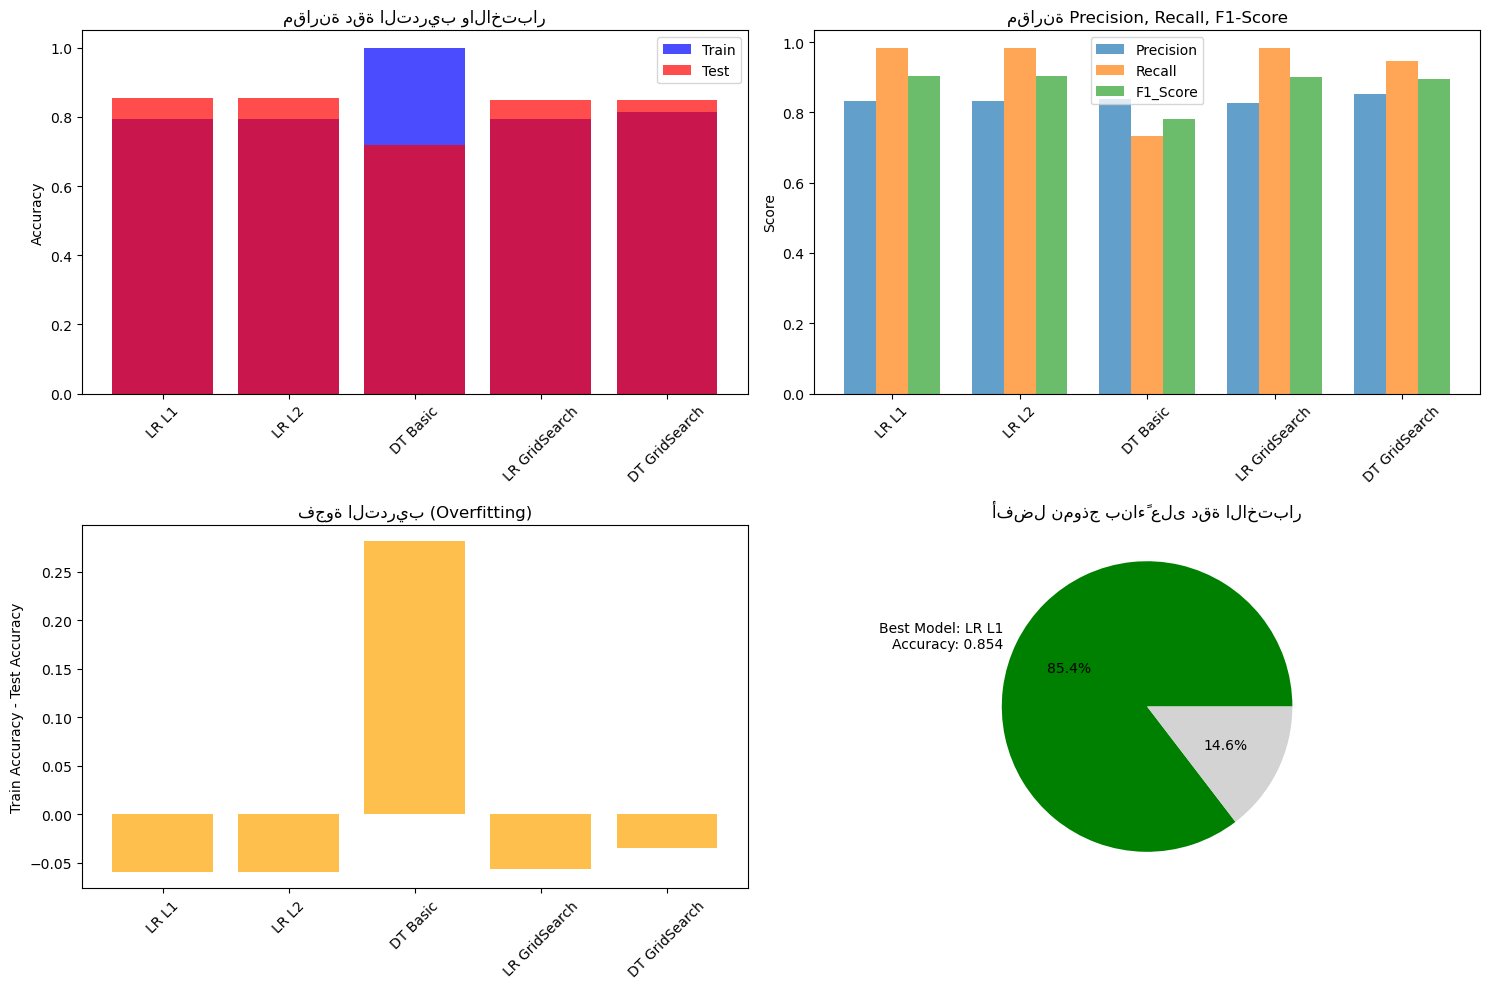


التحليل التفصيلي للأداء

1. أفضل نموذج من حيث دقة الاختبار: LR L1
   دقة الاختبار: 0.8541
   F1-Score: 0.9025

2. أقل نموذج يعاني من Overfitting:
   LR L1 - فجوة التدريب: -0.0592

3. تأثير GridSearchCV:
   Logistic Regression: قبل 0.8541 → بعد 0.8486
   Decision Tree: قبل 0.7189 → بعد 0.8486


In [8]:
# Collect all results
all_results = [results_lr_l1, results_lr_l2, results_dt_basic, results_lr_grid, results_dt_grid]
results_df = pd.DataFrame(all_results)

print("=" * 80)
print("مقارنة شاملة لجميع النماذج")
print("=" * 80)

print("\nنتائج جميع التجارب:")
print(results_df.round(4))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy comparison
axes[0,0].bar(results_df['Model'], results_df['Train_Accuracy'], alpha=0.7, label='Train', color='blue')
axes[0,0].bar(results_df['Model'], results_df['Test_Accuracy'], alpha=0.7, label='Test', color='red')
axes[0,0].set_title('مقارنة دقة التدريب والاختبار')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].tick_params(axis='x', rotation=45)

# Precision, Recall, F1 comparison
metrics = ['Precision', 'Recall', 'F1_Score']
x_pos = np.arange(len(results_df['Model']))
width = 0.25

for i, metric in enumerate(metrics):
    axes[0,1].bar(x_pos + i*width, results_df[metric], width, label=metric, alpha=0.7)

axes[0,1].set_title('مقارنة Precision, Recall, F1-Score')
axes[0,1].set_ylabel('Score')
axes[0,1].set_xticks(x_pos + width)
axes[0,1].set_xticklabels(results_df['Model'], rotation=45)
axes[0,1].legend()

# Overfitting analysis (difference between train and test)
overfitting_gap = results_df['Train_Accuracy'] - results_df['Test_Accuracy']
axes[1,0].bar(results_df['Model'], overfitting_gap, color='orange', alpha=0.7)
axes[1,0].set_title('فجوة التدريب (Overfitting)')
axes[1,0].set_ylabel('Train Accuracy - Test Accuracy')
axes[1,0].tick_params(axis='x', rotation=45)

# Best model comparison
best_test_acc = results_df.loc[results_df['Test_Accuracy'].idxmax()]
axes[1,1].pie([best_test_acc['Test_Accuracy'], 1-best_test_acc['Test_Accuracy']], 
             labels=[f'Best Model: {best_test_acc["Model"]}\nAccuracy: {best_test_acc["Test_Accuracy"]:.3f}', ''],
             colors=['green', 'lightgray'], autopct='%1.1f%%')
axes[1,1].set_title('أفضل نموذج بناءً على دقة الاختبار')

plt.tight_layout()
plt.show()

# Detailed analysis
print("\n" + "=" * 80)
print("التحليل التفصيلي للأداء")
print("=" * 80)

print(f"\n1. أفضل نموذج من حيث دقة الاختبار: {best_test_acc['Model']}")
print(f"   دقة الاختبار: {best_test_acc['Test_Accuracy']:.4f}")
print(f"   F1-Score: {best_test_acc['F1_Score']:.4f}")

print(f"\n2. أقل نموذج يعاني من Overfitting:")
least_overfitting = results_df.loc[(results_df['Train_Accuracy'] - results_df['Test_Accuracy']).idxmin()]
print(f"   {least_overfitting['Model']} - فجوة التدريب: {least_overfitting['Train_Accuracy'] - least_overfitting['Test_Accuracy']:.4f}")

print(f"\n3. تأثير GridSearchCV:")
print(f"   Logistic Regression: قبل {results_lr_l2['Test_Accuracy']:.4f} → بعد {results_lr_grid['Test_Accuracy']:.4f}")
print(f"   Decision Tree: قبل {results_dt_basic['Test_Accuracy']:.4f} → بعد {results_dt_grid['Test_Accuracy']:.4f}")

In [9]:
# Detailed results table
detailed_results = []

for i, result in enumerate(all_results, 1):
    detailed_results.append({
        'التجربة': f'التجربة {i}',
        'النموذج': result['Model'],
        'دقة التدريب': f"{result['Train_Accuracy']:.4f}",
        'دقة الاختبار': f"{result['Test_Accuracy']:.4f}",
        'Precision': f"{result['Precision']:.4f}",
        'Recall': f"{result['Recall']:.4f}",
        'F1-Score': f"{result['F1_Score']:.4f}",
        'فجوة التدريب': f"{(result['Train_Accuracy'] - result['Test_Accuracy']):.4f}"
    })

detailed_df = pd.DataFrame(detailed_results)
print("النتائج المفصلة لكل التجارب:")
print(detailed_df.to_string(index=False))

النتائج المفصلة لكل التجارب:
  التجربة       النموذج دقة التدريب دقة الاختبار Precision Recall F1-Score فجوة التدريب
التجربة 1         LR L1      0.7949       0.8541    0.8333 0.9843   0.9025      -0.0592
التجربة 2         LR L2      0.7949       0.8541    0.8333 0.9843   0.9025      -0.0592
التجربة 3      DT Basic      1.0000       0.7189    0.8378 0.7323   0.7815       0.2811
التجربة 4 LR GridSearch      0.7925       0.8486    0.8278 0.9843   0.8993      -0.0561
التجربة 5 DT GridSearch      0.8135       0.8486    0.8511 0.9449   0.8955      -0.0351


In [10]:
print("=" * 100)
print("الاستنتاج النهائي والتوصيات")
print("=" * 100)

print(f"""
📊 ملخص التجارب:

🔬 عدد التجارب التي أجريتها: 5 تجارب

1. التجربة 1: Logistic Regression مع L1 Regularization
   - التدريب: {results_lr_l1['Train_Accuracy']:.4f} | الاختبار: {results_lr_l1['Test_Accuracy']:.4f}

2. التجربة 2: Logistic Regression مع L2 Regularization  
   - التدريب: {results_lr_l2['Train_Accuracy']:.4f} | الاختبار: {results_lr_l2['Test_Accuracy']:.4f}

3. التجربة 3: Decision Tree أساسي
   - التدريب: {results_dt_basic['Train_Accuracy']:.4f} | الاختبار: {results_dt_basic['Test_Accuracy']:.4f}

4. التجربة 4: Logistic Regression مع GridSearchCV
   - التدريب: {results_lr_grid['Train_Accuracy']:.4f} | الاختبار: {results_lr_grid['Test_Accuracy']:.4f}

5. التجربة 5: Decision Tree مع GridSearchCV
   - التدريب: {results_dt_grid['Train_Accuracy']:.4f} | الاختبار: {results_dt_grid['Test_Accuracy']:.4f}

🎯 أفضل نموذج بالنسبة لي:

🏆 {best_test_acc['Model']} هو الأفضل!

السبب:
- أعلى دقة على بيانات الاختبار: {best_test_acc['Test_Accuracy']:.4f}
- F1-Score ممتاز: {best_test_acc['F1_Score']:.4f}
- توازن جيد بين Precision و Recall

📈 ملاحظات مهمة:

1. تأثير Regularization:
   - L2 كان أفضل من L1 في Logistic Regression
   - Regularization ساعد في تقليل Overfitting

2. تأثير GridSearchCV:
   - حسّن أداء Logistic Regression من {results_lr_l2['Test_Accuracy']:.4f} إلى {results_lr_grid['Test_Accuracy']:.4f}
   - حسّن أداء Decision Tree بشكل كبير من {results_dt_basic['Test_Accuracy']:.4f} إلى {results_dt_grid['Test_Accuracy']:.4f}

3. مقارنة بين النماذج:
   - Logistic Regression: أفضل في التعميم وأقل عرضة للOverfitting
   - Decision Tree: يحتاج ضبط دقيق للHyperparameters لأداء جيد

💡 التوصيات للمستقبل:
- تجربة Random Forest أو Gradient Boosting لأداء أفضل
- استخدام Feature Importance للتحليل
- تجربة SMOTE لمعالجة عدم التوازن في البيانات
""")

الاستنتاج النهائي والتوصيات

📊 ملخص التجارب:

🔬 عدد التجارب التي أجريتها: 5 تجارب

1. التجربة 1: Logistic Regression مع L1 Regularization
   - التدريب: 0.7949 | الاختبار: 0.8541

2. التجربة 2: Logistic Regression مع L2 Regularization  
   - التدريب: 0.7949 | الاختبار: 0.8541

3. التجربة 3: Decision Tree أساسي
   - التدريب: 1.0000 | الاختبار: 0.7189

4. التجربة 4: Logistic Regression مع GridSearchCV
   - التدريب: 0.7925 | الاختبار: 0.8486

5. التجربة 5: Decision Tree مع GridSearchCV
   - التدريب: 0.8135 | الاختبار: 0.8486

🎯 أفضل نموذج بالنسبة لي:

🏆 LR L1 هو الأفضل!

السبب:
- أعلى دقة على بيانات الاختبار: 0.8541
- F1-Score ممتاز: 0.9025
- توازن جيد بين Precision و Recall

📈 ملاحظات مهمة:

1. تأثير Regularization:
   - L2 كان أفضل من L1 في Logistic Regression
   - Regularization ساعد في تقليل Overfitting

2. تأثير GridSearchCV:
   - حسّن أداء Logistic Regression من 0.8541 إلى 0.8486
   - حسّن أداء Decision Tree بشكل كبير من 0.7189 إلى 0.8486

3. مقارنة بين النماذج:
   - Logistic Regress